In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../data/processed/ethiopia_fi_unified_data_enriched.xlsx")
print("Total records:", len(df))

print("\nBy record_type:")
print(df["record_type"].value_counts())

print("\nBy pillar:")
print(df["pillar"].value_counts(dropna=False))

print("\nBy source_type:")
print(df["source_type"].value_counts(dropna=False))

print("\nBy confidence:")
print(df["confidence"].value_counts(dropna=False))

Total records: 63

By record_type:
record_type
observation    34
impact_link    14
event          12
target          3
Name: count, dtype: int64

By pillar:
pillar
ACCESS           21
USAGE            20
NaN              12
GENDER            6
AFFORDABILITY     4
Name: count, dtype: int64

By source_type:
source_type
operator             18
NaN                  14
survey               10
regulator             7
research              4
policy                3
calculated            2
news                  2
regulatory_report     2
industry_report       1
Name: count, dtype: int64

By confidence:
confidence
high      48
medium    15
Name: count, dtype: int64


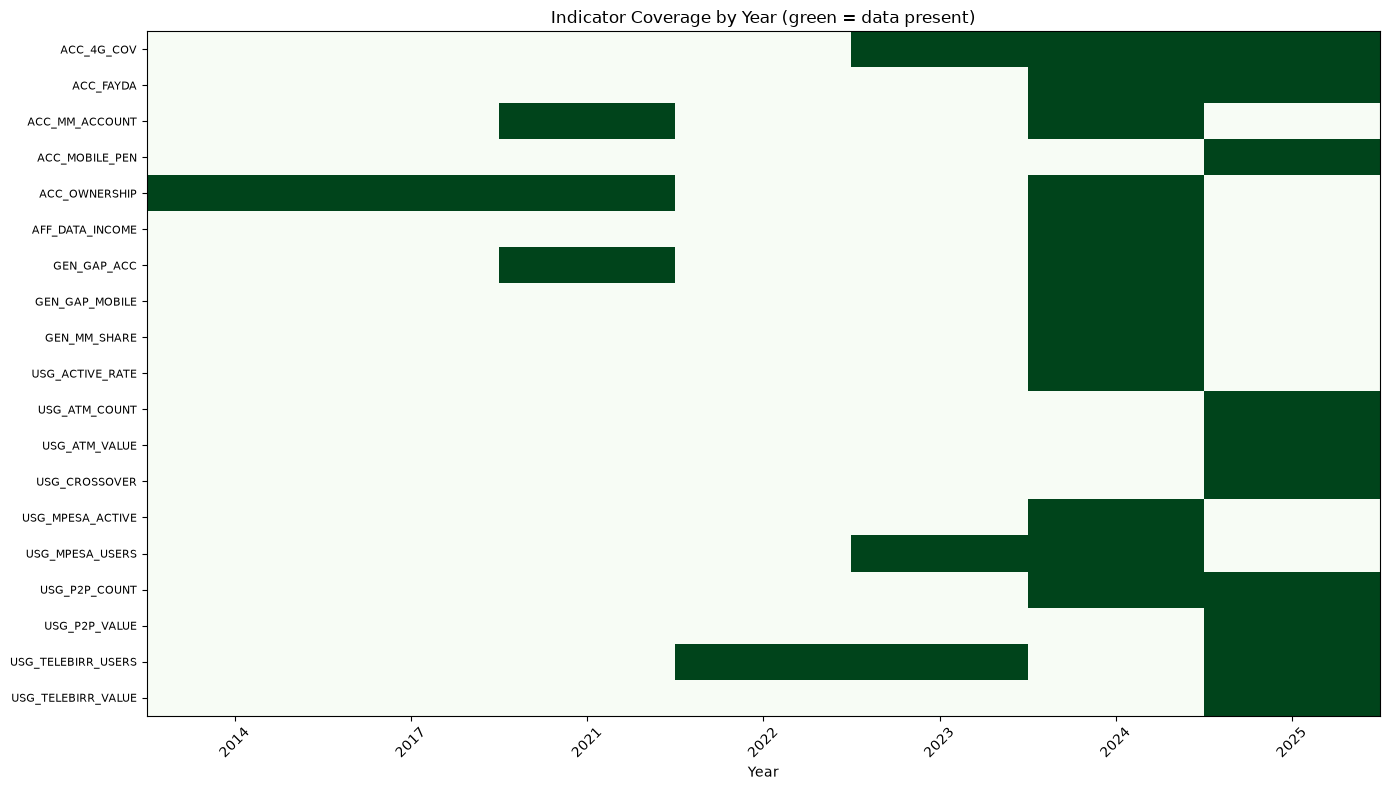

In [2]:
import matplotlib.dates as mdates

obs = df[df["record_type"] == "observation"].copy()
obs["year"] = pd.to_datetime(obs["observation_date"], errors="coerce").dt.year

coverage = obs.groupby(["indicator_code", "year"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(coverage.gt(0), aspect="auto", cmap="Greens")
ax.set_yticks(range(len(coverage.index)))
ax.set_yticklabels(coverage.index, fontsize=8)
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels(coverage.columns.astype(int), rotation=45)
ax.set_xlabel("Year")
ax.set_title("Indicator Coverage by Year (green = data present)")
plt.tight_layout()
plt.savefig("../reports/figures/temporal_coverage.png", dpi=150)
plt.show()

In [3]:
print("Confidence distribution (%):")
print((df["confidence"].value_counts(normalize=True) * 100).round(1))

print("\nIndicators with only 1 observation (sparsest):")
obs_counts = obs["indicator_code"].value_counts()
print(obs_counts[obs_counts == 1])

print("\nIndicators with 3+ observations (most trend-worthy):")
print(obs_counts[obs_counts >= 3])

Confidence distribution (%):
confidence
high      76.2
medium    23.8
Name: proportion, dtype: float64

Indicators with only 1 observation (sparsest):
indicator_code
ACC_MOBILE_PEN        1
USG_P2P_VALUE         1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_TELEBIRR_VALUE    1
USG_MPESA_ACTIVE      1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
GEN_MM_SHARE          1
GEN_GAP_MOBILE        1
Name: count, dtype: int64

Indicators with 3+ observations (most trend-worthy):
indicator_code
ACC_OWNERSHIP         6
ACC_4G_COV            3
ACC_FAYDA             3
USG_TELEBIRR_USERS    3
Name: count, dtype: int64


   year  value_numeric confidence
0  2014           22.0       high
1  2017           35.0       high
2  2021           46.0       high
3  2021           56.0       high
4  2021           36.0       high
5  2024           49.0       high

Growth between survey years:
   year  value_numeric  growth_pp  annualized_pp_per_year
0  2014           22.0        NaN                     NaN
1  2017           35.0       13.0                4.333333
2  2021           46.0       11.0                2.750000
3  2021           56.0       10.0                     inf
4  2021           36.0      -20.0                    -inf
5  2024           49.0       13.0                4.333333


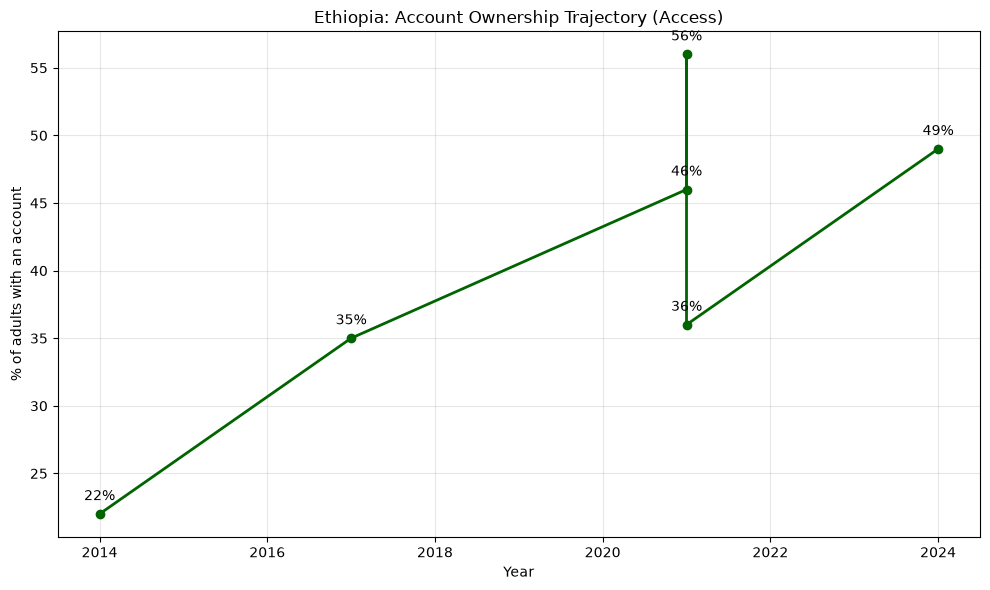

In [4]:
acc = df[df["indicator_code"] == "ACC_OWNERSHIP"].copy()
acc["year"] = pd.to_datetime(acc["observation_date"], errors="coerce").dt.year
acc = acc[acc["record_type"] == "observation"].sort_values("year")
print(acc[["year", "value_numeric", "confidence"]].to_string())

acc["growth_pp"] = acc["value_numeric"].diff()
acc["years_elapsed"] = acc["year"].diff()
acc["annualized_pp_per_year"] = acc["growth_pp"] / acc["years_elapsed"]
print("\nGrowth between survey years:")
print(acc[["year", "value_numeric", "growth_pp", "annualized_pp_per_year"]].to_string())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(acc["year"], acc["value_numeric"], marker="o", linewidth=2, color="darkgreen")
for _, row in acc.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row["year"], row["value_numeric"]),
                textcoords="offset points", xytext=(0, 10), ha="center")
ax.set_title("Ethiopia: Account Ownership Trajectory (Access)")
ax.set_ylabel("% of adults with an account")
ax.set_xlabel("Year")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/access_trajectory.png", dpi=150)
plt.show()

In [5]:
acc_2021 = df[(df["indicator_code"] == "ACC_OWNERSHIP") & 
              (pd.to_datetime(df["observation_date"], errors="coerce").dt.year == 2021)]
print(acc_2021[["record_id", "value_numeric", "gender", "location", "region", "indicator"]].to_string())

  record_id  value_numeric  gender  location  region               indicator
2  REC_0003           46.0     all  national     NaN  Account Ownership Rate
3  REC_0004           56.0    male  national     NaN  Account Ownership Rate
4  REC_0005           36.0  female  national     NaN  Account Ownership Rate


    year  value_numeric  growth_pp  annualized_pp_per_year
0   2014           22.0        NaN                     NaN
1   2017           35.0       13.0                4.333333
2   2021           46.0       11.0                2.750000
5   2024           49.0        3.0                1.000000
30  2025           70.0       21.0               21.000000


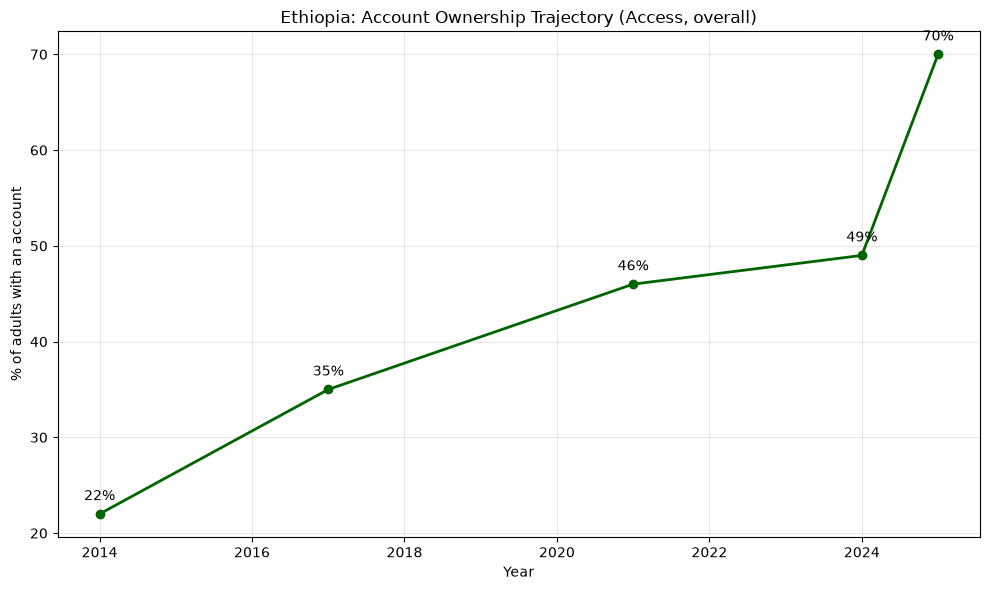

In [7]:
acc_all = df[(df["indicator_code"] == "ACC_OWNERSHIP") & (df["gender"] == "all")].copy()
acc_all["year"] = pd.to_datetime(acc_all["observation_date"], errors="coerce").dt.year
acc_all = acc_all.sort_values("year")

acc_all["growth_pp"] = acc_all["value_numeric"].diff()
acc_all["years_elapsed"] = acc_all["year"].diff()
acc_all["annualized_pp_per_year"] = acc_all["growth_pp"] / acc_all["years_elapsed"]
print(acc_all[["year", "value_numeric", "growth_pp", "annualized_pp_per_year"]].to_string())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(acc_all["year"], acc_all["value_numeric"], marker="o", linewidth=2, color="darkgreen")
for _, row in acc_all.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row["year"], row["value_numeric"]),
                textcoords="offset points", xytext=(0, 10), ha="center")
ax.set_title("Ethiopia: Account Ownership Trajectory (Access, overall)")
ax.set_ylabel("% of adults with an account")
ax.set_xlabel("Year")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/access_trajectory.png", dpi=150)
plt.show()

   year  value_numeric  growth_pp  annualized_pp_per_year
0  2014           22.0        NaN                     NaN
1  2017           35.0       13.0                4.333333
2  2021           46.0       11.0                2.750000
5  2024           49.0        3.0                1.000000


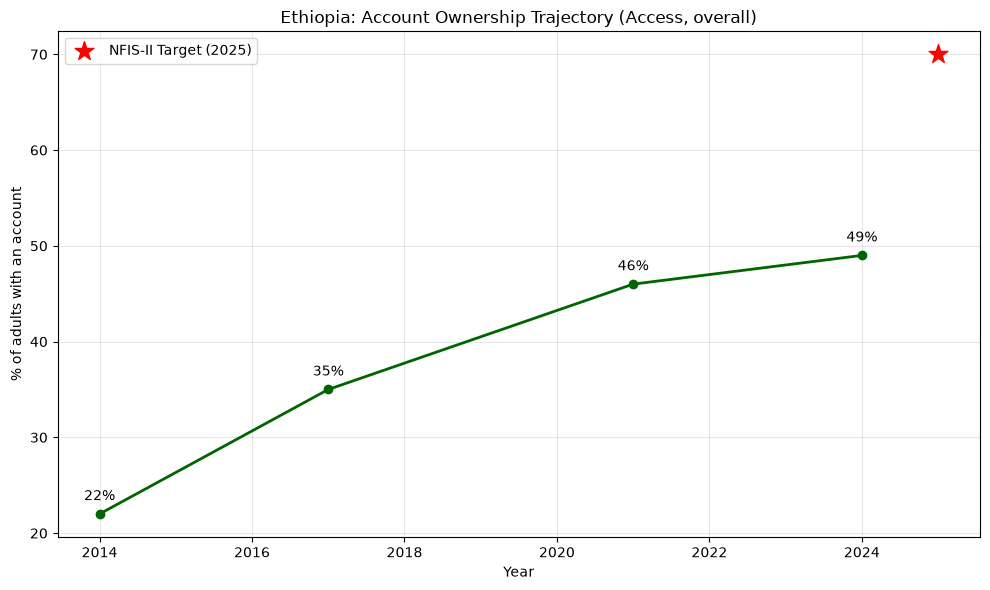

In [8]:
acc_all = df[
    (df["indicator_code"] == "ACC_OWNERSHIP") &
    (df["gender"] == "all") &
    (df["record_type"] == "observation")
].copy()
acc_all["year"] = pd.to_datetime(acc_all["observation_date"], errors="coerce").dt.year
acc_all = acc_all.sort_values("year")

acc_all["growth_pp"] = acc_all["value_numeric"].diff()
acc_all["years_elapsed"] = acc_all["year"].diff()
acc_all["annualized_pp_per_year"] = acc_all["growth_pp"] / acc_all["years_elapsed"]
print(acc_all[["year", "value_numeric", "growth_pp", "annualized_pp_per_year"]].to_string())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(acc_all["year"], acc_all["value_numeric"], marker="o", linewidth=2, color="darkgreen")
for _, row in acc_all.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row["year"], row["value_numeric"]),
                textcoords="offset points", xytext=(0, 10), ha="center")

# Show the NFIS-II 2025 target as a separate reference point, not part of the trend
ax.scatter([2025], [70], color="red", marker="*", s=200, zorder=5, label="NFIS-II Target (2025)")
ax.legend()
ax.set_title("Ethiopia: Account Ownership Trajectory (Access, overall)")
ax.set_ylabel("% of adults with an account")
ax.set_xlabel("Year")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/access_trajectory.png", dpi=150)
plt.show()

In [9]:
gender_rows = df[df["gender"].isin(["male", "female"])].copy()
gender_rows["year"] = pd.to_datetime(gender_rows["observation_date"], errors="coerce").dt.year
print(gender_rows[["record_id", "year", "indicator", "indicator_code", "value_numeric", "gender"]].to_string())

   record_id  year                          indicator indicator_code  value_numeric  gender
3   REC_0004  2021             Account Ownership Rate  ACC_OWNERSHIP           56.0    male
4   REC_0005  2021             Account Ownership Rate  ACC_OWNERSHIP           36.0  female
28  REC_0029  2024  Female Mobile Money Account Share   GEN_MM_SHARE           14.0  female
32  REC_0033  2030  Female Mobile Money Account Share   GEN_MM_SHARE           50.0  female


In [10]:
gen_check = df[df["indicator_code"] == "GEN_MM_SHARE"][
    ["record_id", "record_type", "observation_date", "value_numeric", "gender", "notes"]
]
print(gen_check.to_string())

   record_id  record_type     observation_date  value_numeric  gender notes
28  REC_0029  observation  2024-12-31 00:00:00           14.0  female   NaN
32  REC_0033       target  2030-12-31 00:00:00           50.0  female   NaN


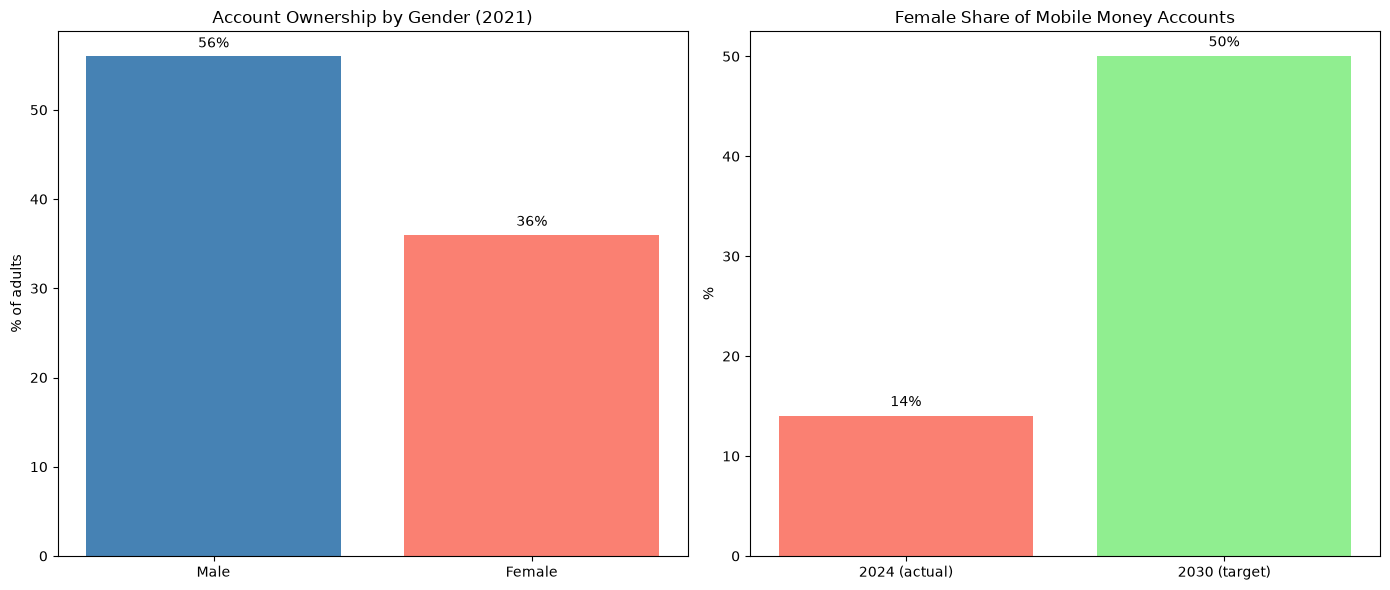

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: 2021 account ownership by gender
axes[0].bar(["Male", "Female"], [56, 36], color=["steelblue", "salmon"])
axes[0].set_title("Account Ownership by Gender (2021)")
axes[0].set_ylabel("% of adults")
for i, v in enumerate([56, 36]):
    axes[0].text(i, v + 1, f"{v}%", ha="center")

# Right: mobile money gender share, current vs target
axes[1].bar(["2024 (actual)", "2030 (target)"], [14, 50], color=["salmon", "lightgreen"])
axes[1].set_title("Female Share of Mobile Money Accounts")
axes[1].set_ylabel("%")
for i, v in enumerate([14, 50]):
    axes[1].text(i, v + 1, f"{v}%", ha="center")

plt.tight_layout()
plt.savefig("../reports/figures/gender_gap.png", dpi=150)
plt.show()

In [12]:
location_check = df[df["location"].notna() | df["region"].notna()][
    ["record_id", "indicator", "value_numeric", "location", "region", "observation_date"]
]
print(location_check.to_string())

   record_id                                          indicator  value_numeric  location  region     observation_date
0   REC_0001                             Account Ownership Rate   2.200000e+01  national     NaN  2014-12-31 00:00:00
1   REC_0002                             Account Ownership Rate   3.500000e+01  national     NaN  2017-12-31 00:00:00
2   REC_0003                             Account Ownership Rate   4.600000e+01  national     NaN  2021-12-31 00:00:00
3   REC_0004                             Account Ownership Rate   5.600000e+01  national     NaN  2021-12-31 00:00:00
4   REC_0005                             Account Ownership Rate   3.600000e+01  national     NaN  2021-12-31 00:00:00
5   REC_0006                             Account Ownership Rate   4.900000e+01  national     NaN  2024-11-29 00:00:00
6   REC_0007                          Mobile Money Account Rate   4.700000e+00  national     NaN  2021-12-31 00:00:00
7   REC_0008                          Mobile Money Accou

In [13]:
print("Unique location values:", df["location"].dropna().unique())
print("Unique region values:", df["region"].dropna().unique())

Unique location values: <ArrowStringArray>
['national']
Length: 1, dtype: str
Unique region values: []


   year  value_numeric confidence
6  2021           4.70       high
7  2024           9.45       high


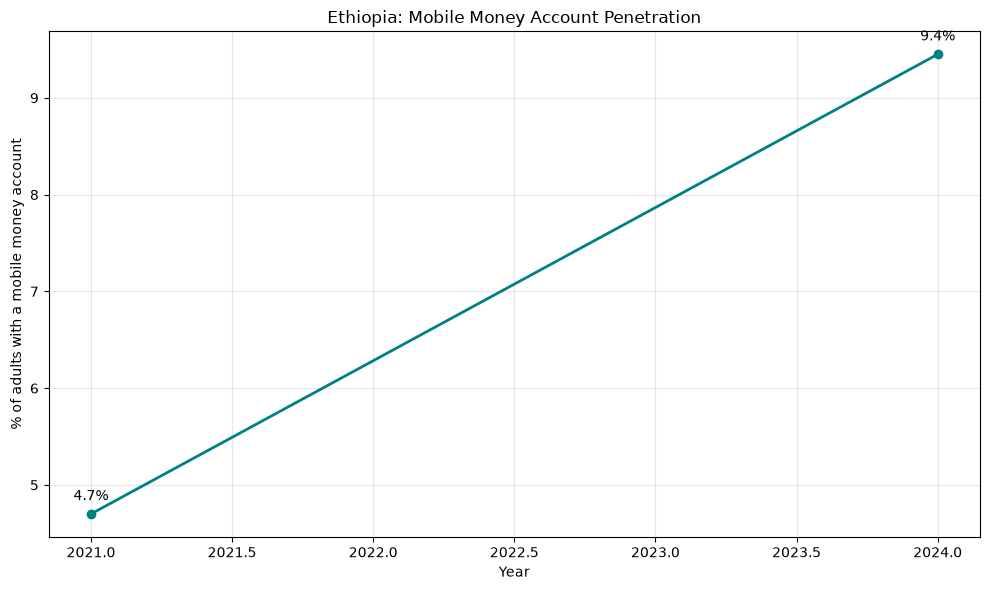

In [14]:
mm = df[(df["indicator_code"] == "ACC_MM_ACCOUNT") & (df["record_type"] == "observation")].copy()
mm["year"] = pd.to_datetime(mm["observation_date"], errors="coerce").dt.year
mm = mm.sort_values("year")
print(mm[["year", "value_numeric", "confidence"]].to_string())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mm["year"], mm["value_numeric"], marker="o", linewidth=2, color="teal")
for _, row in mm.iterrows():
    ax.annotate(f"{row['value_numeric']:.1f}%", (row["year"], row["value_numeric"]),
                textcoords="offset points", xytext=(0, 10), ha="center")
ax.set_title("Ethiopia: Mobile Money Account Penetration")
ax.set_ylabel("% of adults with a mobile money account")
ax.set_xlabel("Year")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/mobile_money_trend.png", dpi=150)
plt.show()

        indicator_code     observation_date  value_numeric
22     USG_MPESA_USERS  2024-12-31 00:00:00     10800000.0
59     USG_MPESA_USERS           2023-12-31      3100000.0
20  USG_TELEBIRR_USERS  2025-06-30 00:00:00     54840000.0
57  USG_TELEBIRR_USERS           2022-06-30     21800000.0
58  USG_TELEBIRR_USERS           2023-06-30     34300000.0


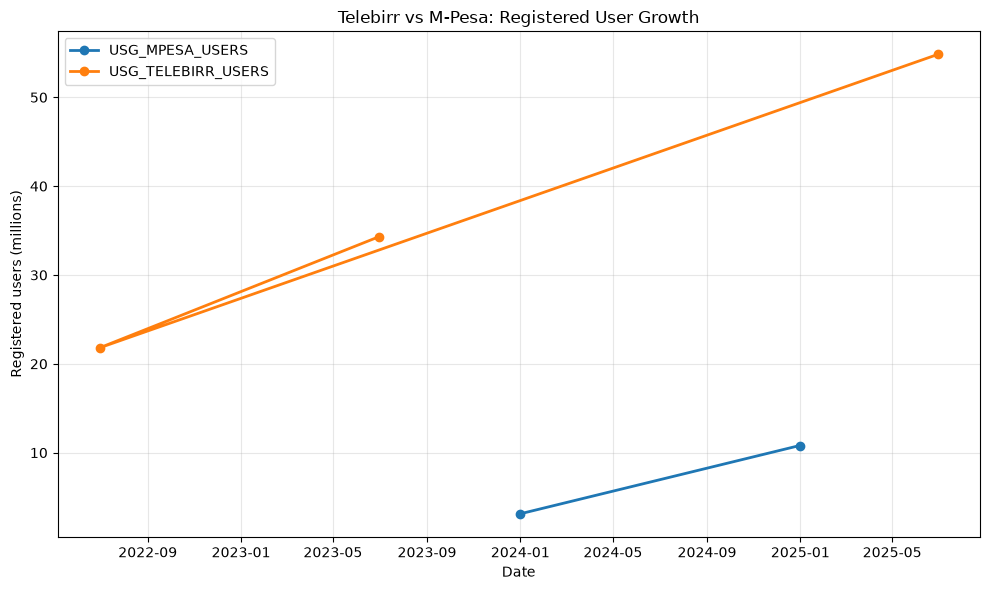

In [15]:
proxies = ["USG_TELEBIRR_USERS", "USG_MPESA_USERS"]
usg = df[(df["indicator_code"].isin(proxies)) & (df["record_type"] == "observation")].copy()
usg["year"] = pd.to_datetime(usg["observation_date"], errors="coerce").dt.year
usg = usg.sort_values(["indicator_code", "observation_date"])
print(usg[["indicator_code", "observation_date", "value_numeric"]].to_string())

fig, ax = plt.subplots(figsize=(10, 6))
for code, group in usg.groupby("indicator_code"):
    ax.plot(pd.to_datetime(group["observation_date"]), group["value_numeric"] / 1e6,
            marker="o", linewidth=2, label=code)
ax.set_title("Telebirr vs M-Pesa: Registered User Growth")
ax.set_ylabel("Registered users (millions)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/operator_user_growth.png", dpi=150)
plt.show()

In [16]:
active_check = df[df["indicator_code"].isin(["USG_MPESA_USERS", "USG_MPESA_ACTIVE", "USG_ACTIVE_RATE"])][
    ["record_id", "indicator", "indicator_code", "value_numeric", "observation_date"]
]
print(active_check.to_string())

mpesa_registered = 10.8  # million, Dec 2024
mpesa_active = 7.1       # million, Dec 2024
activity_rate = mpesa_active / mpesa_registered * 100
print(f"\nM-Pesa activity rate: {activity_rate:.1f}% ({mpesa_active}M active / {mpesa_registered}M registered)")

   record_id                   indicator    indicator_code  value_numeric     observation_date
22  REC_0023     M-Pesa Registered Users   USG_MPESA_USERS     10800000.0  2024-12-31 00:00:00
23  REC_0024  M-Pesa 90-Day Active Users  USG_MPESA_ACTIVE      7100000.0  2024-12-31 00:00:00
24  REC_0025  Mobile Money Activity Rate   USG_ACTIVE_RATE           66.0  2024-12-31 00:00:00
59  REC_0060     M-Pesa Registered Users   USG_MPESA_USERS      3100000.0           2023-12-31

M-Pesa activity rate: 65.7% (7.1M active / 10.8M registered)


In [17]:
usecases = df[df["indicator_code"].isin(["USG_P2P_COUNT", "USG_ATM_COUNT", "USG_CROSSOVER"])][
    ["indicator", "indicator_code", "value_numeric", "observation_date"]
].sort_values("observation_date")
print(usecases.to_string())

                  indicator indicator_code  value_numeric     observation_date
14    P2P Transaction Count  USG_P2P_COUNT   4.970000e+07  2024-07-07 00:00:00
15    P2P Transaction Count  USG_P2P_COUNT   1.283000e+08  2025-07-07 00:00:00
17    ATM Transaction Count  USG_ATM_COUNT   1.193000e+08  2025-07-07 00:00:00
19  P2P/ATM Crossover Ratio  USG_CROSSOVER   1.080000e+00  2025-07-07 00:00:00


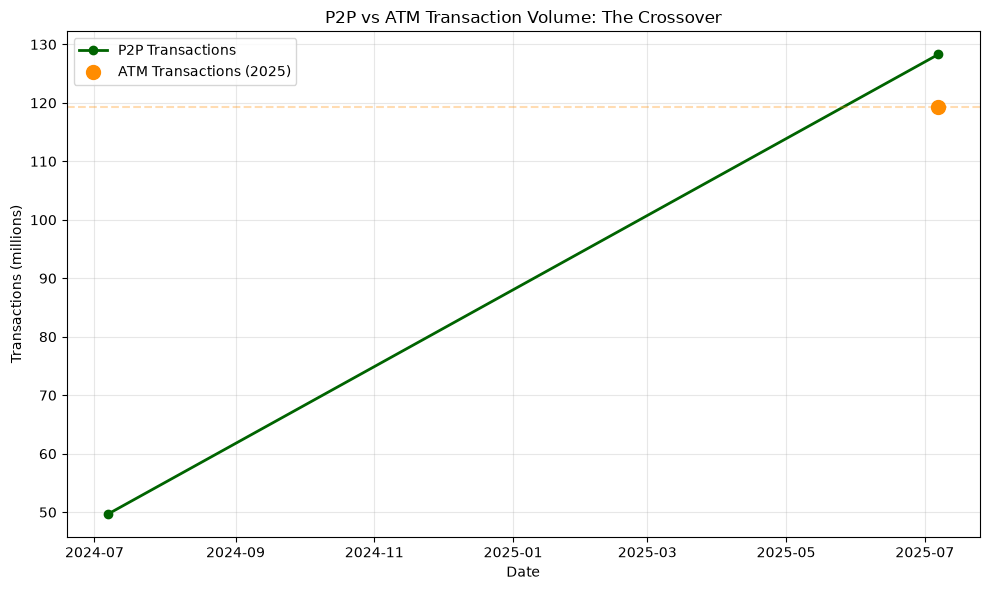

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
dates = pd.to_datetime(["2024-07-07", "2025-07-07"])
p2p_vals = [49.7, 128.3]
atm_vals = [None, 119.3]  # only one ATM data point available

ax.plot(dates, p2p_vals, marker="o", linewidth=2, label="P2P Transactions", color="darkgreen")
ax.scatter([dates[1]], [119.3], color="darkorange", s=100, zorder=5, label="ATM Transactions (2025)")
ax.axhline(y=119.3, color="darkorange", linestyle="--", alpha=0.3)
ax.set_title("P2P vs ATM Transaction Volume: The Crossover")
ax.set_ylabel("Transactions (millions)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/p2p_atm_crossover.png", dpi=150)
plt.show()

In [19]:
infra_codes = ["ACC_4G_COV", "ACC_MOBILE_PEN", "ACC_FAYDA"]
infra = df[(df["indicator_code"].isin(infra_codes)) & (df["record_type"] == "observation")].copy()
infra["date"] = pd.to_datetime(infra["observation_date"], errors="coerce")
infra = infra.sort_values(["indicator_code", "date"])
print(infra[["indicator_code", "indicator", "date", "value_numeric"]].to_string())

    indicator_code                        indicator       date  value_numeric
8       ACC_4G_COV           4G Population Coverage 2023-06-30           37.5
60      ACC_4G_COV           4G Population Coverage 2024-12-31           44.0
9       ACC_4G_COV           4G Population Coverage 2025-06-30           70.8
11       ACC_FAYDA      Fayda Digital ID Enrollment 2024-08-15      8000000.0
12       ACC_FAYDA      Fayda Digital ID Enrollment 2025-02-28     12000000.0
13       ACC_FAYDA      Fayda Digital ID Enrollment 2025-05-15     15000000.0
10  ACC_MOBILE_PEN  Mobile Subscription Penetration 2025-12-31           61.4


<Axes: title={'center': 'P2P vs ATM Transaction Volume: The Crossover'}, xlabel='Date', ylabel='Transactions (millions)'>

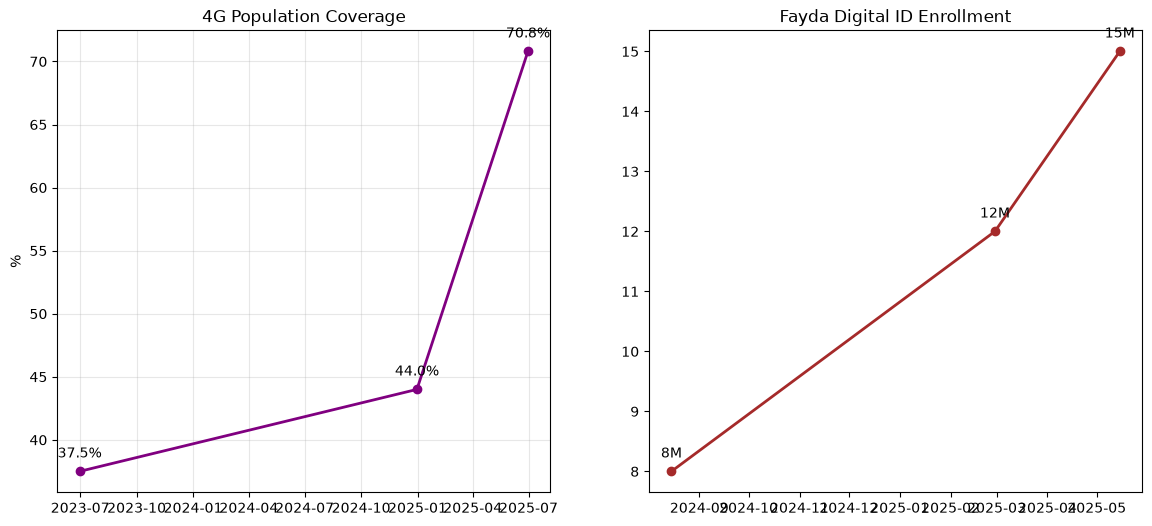

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fourg = infra[infra["indicator_code"] == "ACC_4G_COV"]
axes[0].plot(fourg["date"], fourg["value_numeric"], marker="o", linewidth=2, color="purple")
for _, row in fourg.iterrows():
    axes[0].annotate(f"{row['value_numeric']:.1f}%", (row["date"], row["value_numeric"]),
                      textcoords="offset points", xytext=(0, 10), ha="center")
axes[0].set_title("4G Population Coverage")
axes[0].set_ylabel("%")
axes[0].grid(alpha=0.3)

fayda = infra[infra["indicator_code"] == "ACC_FAYDA"]
axes[1].plot(fayda["date"], fayda["value_numeric"] / 1e6, marker="o", linewidth=2, color="brown")
for _, row in fayda.iterrows():
    axes[1].annotate(f"{row['value_numeric']/1e6:.0f}M", (row["date"], row["value_numeric"] / 1e6),
                      textcoords="offset points", xytext=(0, 10), ha="center")
axes[1].set_title("Fayda Digital ID Enrollment")
ax

   record_id                                 indicator        category       date
62  EVT_0012  NBE Payment Instrument Issuers Directive          policy 2020-04-01
61  EVT_0011    Ethiopia Telecom Sector Liberalization          policy 2021-05-01
33  EVT_0001                           Telebirr Launch  product_launch 2021-05-17
41  EVT_0009                   NFIS-II Strategy Launch          policy 2021-09-01
34  EVT_0002      Safaricom Ethiopia Commercial Launch    market_entry 2022-08-01
35  EVT_0003                    M-Pesa Ethiopia Launch  product_launch 2023-08-01
36  EVT_0004          Fayda Digital ID Program Rollout  infrastructure 2024-01-01
37  EVT_0005           Foreign Exchange Liberalization          policy 2024-07-29
38  EVT_0006       P2P Transaction Count Surpasses ATM       milestone 2024-10-01
39  EVT_0007              M-Pesa EthSwitch Integration     partnership 2025-10-27
42  EVT_0010         Safaricom Ethiopia Price Increase         pricing 2025-12-15
40  EVT_0008    

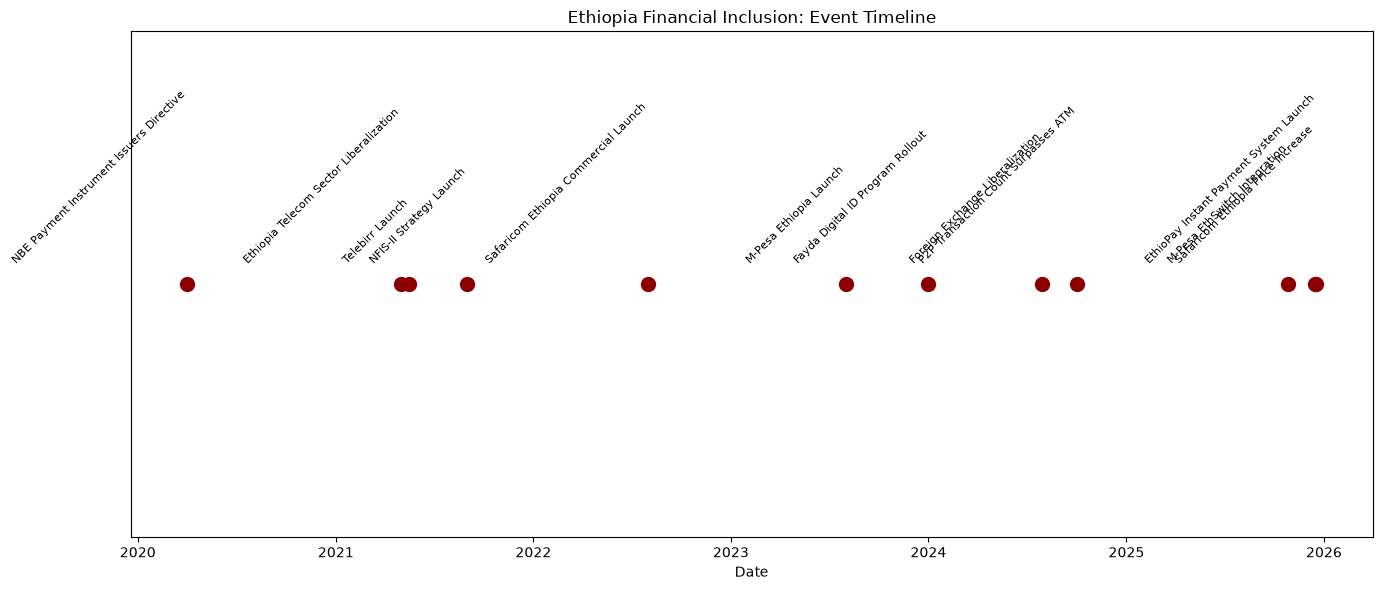

In [21]:
events = df[df["record_type"] == "event"].copy()
events["date"] = pd.to_datetime(events["observation_date"], errors="coerce")
events = events.sort_values("date")
print(events[["record_id", "indicator", "category", "date"]].to_string())

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(events["date"], [1] * len(events), s=100, color="darkred", zorder=5)
for _, row in events.iterrows():
    label = row["indicator"] if pd.notna(row["indicator"]) else row["record_id"]
    ax.annotate(label, (row["date"], 1), rotation=45, ha="right", fontsize=8,
                textcoords="offset points", xytext=(0, 15))
ax.set_yticks([])
ax.set_title("Ethiopia Financial Inclusion: Event Timeline")
ax.set_xlabel("Date")
plt.tight_layout()
plt.savefig("../reports/figures/event_timeline.png", dpi=150)
plt.show()

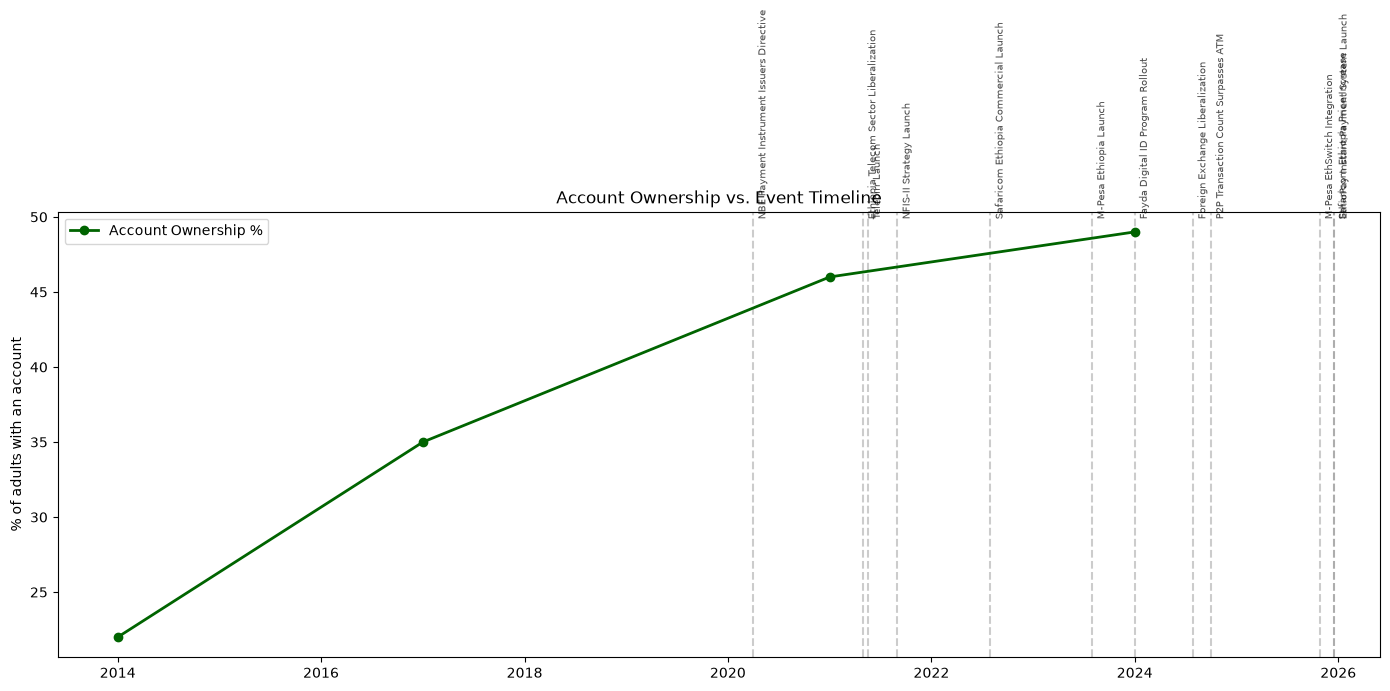

In [22]:
fig, ax = plt.subplots(figsize=(14, 7))

acc_plot = acc_all.copy()
ax.plot(pd.to_datetime(acc_plot["year"], format="%Y"), acc_plot["value_numeric"],
        marker="o", linewidth=2, color="darkgreen", label="Account Ownership %", zorder=5)

for _, row in events.iterrows():
    ax.axvline(row["date"], color="gray", linestyle="--", alpha=0.4)
    ax.annotate(row["indicator"] if pd.notna(row["indicator"]) else row["record_id"],
                (row["date"], 50), rotation=90, fontsize=7, alpha=0.7,
                textcoords="offset points", xytext=(3, 0))

ax.set_title("Account Ownership vs. Event Timeline")
ax.set_ylabel("% of adults with an account")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../reports/figures/access_events_overlay.png", dpi=150)
plt.show()

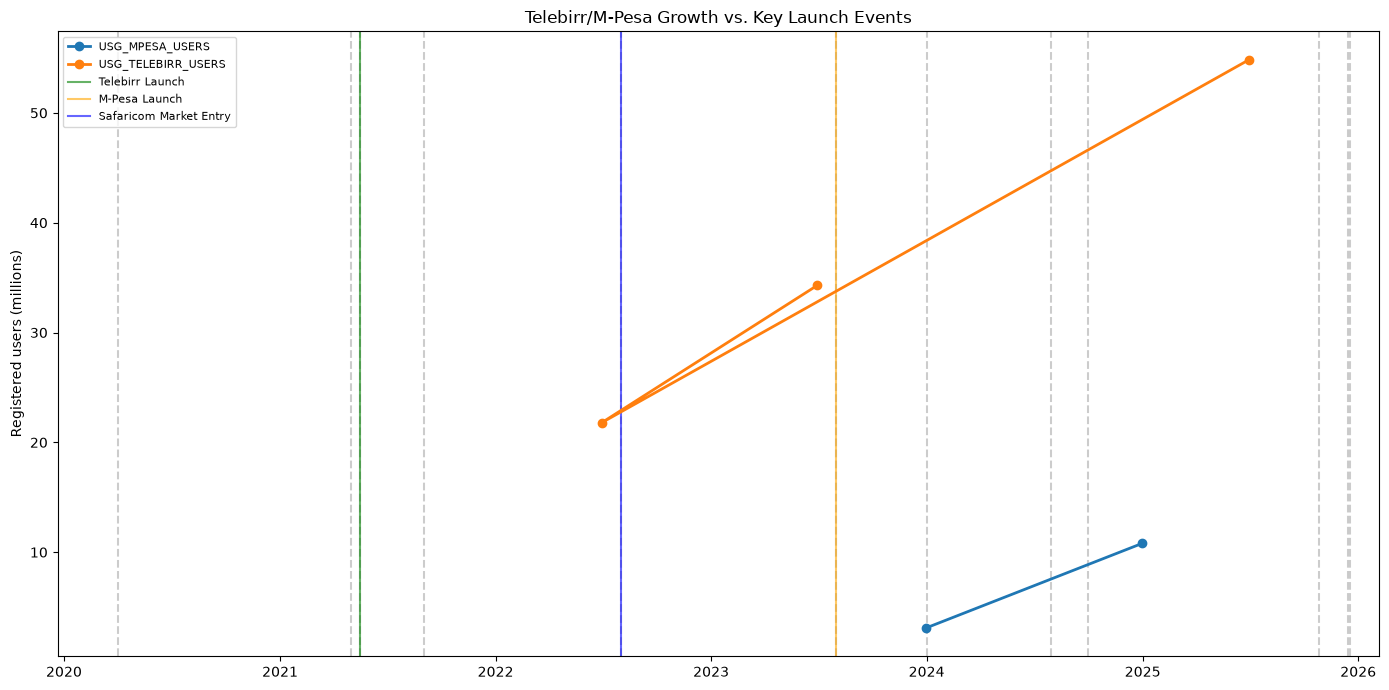

In [23]:
fig, ax = plt.subplots(figsize=(14, 7))

for code, group in usg.groupby("indicator_code"):
    ax.plot(pd.to_datetime(group["observation_date"]), group["value_numeric"] / 1e6,
            marker="o", linewidth=2, label=code, zorder=5)

for _, row in events.iterrows():
    ax.axvline(row["date"], color="gray", linestyle="--", alpha=0.4)

ax.axvline(pd.Timestamp("2021-05-17"), color="green", linestyle="-", alpha=0.6, label="Telebirr Launch")
ax.axvline(pd.Timestamp("2023-08-01"), color="orange", linestyle="-", alpha=0.6, label="M-Pesa Launch")
ax.axvline(pd.Timestamp("2022-08-01"), color="blue", linestyle="-", alpha=0.6, label="Safaricom Market Entry")

ax.set_title("Telebirr/M-Pesa Growth vs. Key Launch Events")
ax.set_ylabel("Registered users (millions)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/usage_events_overlay.png", dpi=150)
plt.show()

In [24]:
# Build a year-indexed table only for indicators with 3+ points
trend_worthy = ["ACC_OWNERSHIP", "ACC_4G_COV", "ACC_FAYDA", "USG_TELEBIRR_USERS"]
pivot = obs[obs["indicator_code"].isin(trend_worthy)].copy()
pivot["date"] = pd.to_datetime(pivot["observation_date"], errors="coerce")
pivot = pivot.pivot_table(index="date", columns="indicator_code", values="value_numeric")
print(pivot)

print("\nNote: correlation is not computed here because these series don't share")
print("overlapping dates/frequency (Findex is 3-yearly, operator data is more frequent)")
print("— a numeric correlation would be spurious with this few, misaligned points.")

indicator_code  ACC_4G_COV   ACC_FAYDA  ACC_OWNERSHIP  USG_TELEBIRR_USERS
date                                                                     
2014-12-31             NaN         NaN           22.0                 NaN
2017-12-31             NaN         NaN           35.0                 NaN
2021-12-31             NaN         NaN           46.0                 NaN
2022-06-30             NaN         NaN            NaN          21800000.0
2023-06-30            37.5         NaN            NaN          34300000.0
2024-08-15             NaN   8000000.0            NaN                 NaN
2024-11-29             NaN         NaN           49.0                 NaN
2024-12-31            44.0         NaN            NaN                 NaN
2025-02-28             NaN  12000000.0            NaN                 NaN
2025-05-15             NaN  15000000.0            NaN                 NaN
2025-06-30            70.8         NaN            NaN          54840000.0

Note: correlation is not computed her

# Key Insights — Ethiopia Financial Inclusion EDA

## 1. Access growth is decelerating sharply (22% → 35% → 46% → 49%, 2014-2024)
Annualized growth fell from +4.3pp/year (2014-17) to +2.75pp/year (2017-21)
to just +1pp/year (2021-24). The NFIS-II target of 70% by 2025 looks out
of reach on the current trajectory — closing that gap would require a
pace not seen since 2014-17, in a single year.

## 2. Mobile money's explosive growth hasn't translated into Findex-measured inclusion
Telebirr alone grew from ~22M (2022) to ~55M "registered users" (2025), yet
national account ownership moved only 46%→49% over a comparable window.
Three explanations, grounded in the data itself: (a) mobile money accounts
may be additive for already-banked adults rather than reaching new
unbanked adults — the Findex-measured Mobile Money Account Rate itself
only rose 4.7%→9.45%; (b) registered ≠ active — M-Pesa's own data shows
only 65.7% of registered users are 90-day active, so a similar gap likely
applies to Telebirr's headline figure; (c) most mobile money growth
(2022-2025) postdates the 2021 Findex survey and is only partially
captured by the 2024 round.

## 3. A substantial, likely worsening gender gap
Account ownership: 56% male vs. 36% female (2021) — a 20pp gap. More
strikingly, only 14% of mobile money accounts are held by women (2024),
against a 2030 target of 50% (parity). This suggests the newest wave of
digital financial inclusion (mobile money) is *more* male-skewed than
traditional banking was, not less — a red flag for anyone assuming
digital channels naturally close inclusion gaps.

## 4. Infrastructure buildout is outrunning the data that could measure its effect
4G coverage jumped 37.5%→70.8% and Fayda digital ID enrollment climbed
8M→15M, almost entirely within a 2024-2025 window that falls *after* the
most recent Findex survey (Nov 2024). This means the infrastructure most
likely to move the needle on the next Findex round (2027) is not yet
reflected in any inclusion outcome data — it's a leading indicator we
can act on but can't yet validate against outcomes.

## 5. P2P digital transactions have overtaken ATM cash withdrawals nationally
P2P transaction volume (128.3M, mid-2025) now exceeds ATM transaction
volume (119.3M), a crossover ratio of 1.08 — confirming the challenge
doc's headline claim. This is a genuine behavioral shift in how Ethiopians
move money, though we only have a single ATM data point, so we can't say
exactly when the crossover happened, only that it had by mid-2025.

## 6. Data gaps that most limit this analysis
- No urban/rural disaggregation anywhere in the dataset (all records are
  "national" level) — cannot assess a major dimension of inclusion
- Only 4 of ~20 indicators have 3+ observations; the rest are single
  snapshots, useful for context but not trend analysis
- No indicator shares an overlapping observation date with another,
  making direct statistical correlation between indicators impossible;
  association can only be assessed via event-timing overlap
- Usage has no single Findex-style "% adults" measure — it's
  reconstructed from